In [6]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import defaultdict

In [2]:

root = Path("/home/linux/Desktop/Dataset/")  # replace with your top-level directory
files = list(root.rglob("*.jsonl"))
total_files = len(files) # Count the number of files
records = []
file_count = 0
line_count = 0
bad_lines = 0
total_lines_to_process = 0

# Iterate through each file in the list 'files'
for file in files:
    # Open each file in read mode with UTF-8 encoding
    with file.open("r", encoding="utf-8") as f:
        # Count each line in the current file
        for line in f:
            total_lines_to_process += 1  # Increment the line counter

# Print out the total number of files and the total lines to process
print(f"Total files: {total_files}, Total lines to process: {total_lines_to_process}")

Total files: 3, Total lines to process: 60000


In [3]:
for p in files:
    file_count += 1
    print(f"Processing file {file_count}/{total_files}: {p}")
    with p.open("r", encoding="utf-8") as f:
        for i, raw in enumerate(f, start=1):
            raw = raw.strip()
            if not raw:
                continue
            try:
                records.append(json.loads(raw))
                line_count += 1
            except json.JSONDecodeError:
                bad_lines += 1
    print(f"  -> lines read: {i}, valid records so far: {line_count}, bad lines so far: {bad_lines}")

df = pd.DataFrame.from_records(records)
print(f"Finished. Files: {total_files}, Records: {len(df)}, Bad lines: {bad_lines}")

Processing file 1/3: /home/linux/Desktop/Dataset/2023-11-05_2023-11-11_Win64_train.jsonl
  -> lines read: 20000, valid records so far: 20000, bad lines so far: 0
Processing file 2/3: /home/linux/Desktop/Dataset/1_train.jsonl
  -> lines read: 20000, valid records so far: 40000, bad lines so far: 0
Processing file 3/3: /home/linux/Desktop/Dataset/2023-10-29_2023-11-04_Win64_train.jsonl
  -> lines read: 20000, valid records so far: 60000, bad lines so far: 0
Finished. Files: 3, Records: 60000, Bad lines: 0


In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   md5                    60000 non-null  str    
 1   sha1                   60000 non-null  str    
 2   sha256                 60000 non-null  str    
 3   tlsh                   60000 non-null  str    
 4   first_submission_date  60000 non-null  int64  
 5   last_analysis_date     60000 non-null  int64  
 6   detection_ratio        60000 non-null  str    
 7   label                  60000 non-null  int64  
 8   file_type              60000 non-null  str    
 9   family                 24704 non-null  str    
 10  family_confidence      24704 non-null  float64
 11  behavior               60000 non-null  object 
 12  file_property          60000 non-null  object 
 13  packer                 60000 non-null  object 
 14  exploit                60000 non-null  object 
 15  group        

,md5,sha1,sha256,tlsh,first_submission_date,last_analysis_date,detection_ratio,label,file_type,family,...,imports,exports,datadirectories,richheader,authenticode,pefilewarnings,week_id,caps,ttps,mbc
0,ad5cf31f8322db0ca568ccca699c767f,d225c3158d5af540f0723399ebdd92ea418cc4d6,00068ab2c8dca97f9df22779d4eb65fe0d9377a7247790...,T1848633427A5204FADDF810368412C134E2767CBB47B0...,1699645720,1702536804,5/76,1,Win64,NaN,...,"{'KERNEL32.dll': ['GetCommandLineW', 'GetEnvir...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[17004619, 7, 17135691, 190, 17070155, 10, 166...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,6,[],[],[]
1,d61de691e80b072d3dd41f5626cece88,ce76b2c09087bb0fe68cb78081cc4acbdf8c5abe,000afe1301d6331a924b0e31c8b8e483b01f1245c6f4bb...,T17F235B0FE21380B9D31B523449667676F836B91922B0...,1699623928,1707299644,31/76,1,Win64,cosmu,...,{},[],"[{'has_relocs': 0, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Damaged Import Table information..., Error pa...",6,[],[],[]
2,57d5fca7f89e62979487537db4d1e840,9688832b41753181e38269b1844e8c1ca3efade6,001000780a9b049cc5301566714a2ba0738270045e2234...,T1E166336461A10EF5ECF7913AC88499549AB3B06343A4...,1699187757,1699978806,43/76,1,Win64,stubo,...,"{'USER32.dll': ['CreateWindowExW', 'MessageBox...",[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...","[17004619, 7, 17135691, 191, 17070155, 10, 166...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...",[Failed parsing FunctionEntry of UNWIND_INFO a...,6,[],[],[]
3,b94441a20f310d96c33d2970408a8fc0,dff7a373b51ccd6835344c9dba1cb8a210da3440,001a83827a3bb4ad8f9cfdefd748a10e9859251ce0cdf0...,T1F055120D07ED24DAF43356B49666819687B4BC712720...,1699356858,1699516200,49/76,1,Win64,expiro,...,"{'ADVAPI32.dll': ['GetTokenInformation', 'SetS...",[],"[{'has_relocs': 0, 'has_dynamic_relocs': 0}, {...","[17001236, 3, 17132308, 16, 16870164, 13, 6553...","{'num_certs': 0, 'self_signed': 0, 'empty_prog...","[Byte 0x..., Suspicious flags set for section...]",6,[],[],[]
4,285867934e6c3e6f6649221b1f252ff7,6023d698b52519a48010fbf30afb481afc30f4d9,001af6bc132767957af589115f7044dbe6145c604f0988...,T1A0256E4273FC1128F0F75F57BE767554A97EBEEA6A41...,1699635141,1720921143,0/77,0,Win64,NaN,...,{'mscoree.dll': ['_CorDllMain']},[],"[{'has_relocs': 1, 'has_dynamic_relocs': 0}, {...",[],"{'num_certs': 2, 'self_signed': 0, 'empty_prog...",[],6,"[{'Capability': 'Access .net resource', 'Names...",[],"[{'Objective': 'DISCOVERY', 'Behavior': 'Analy..."


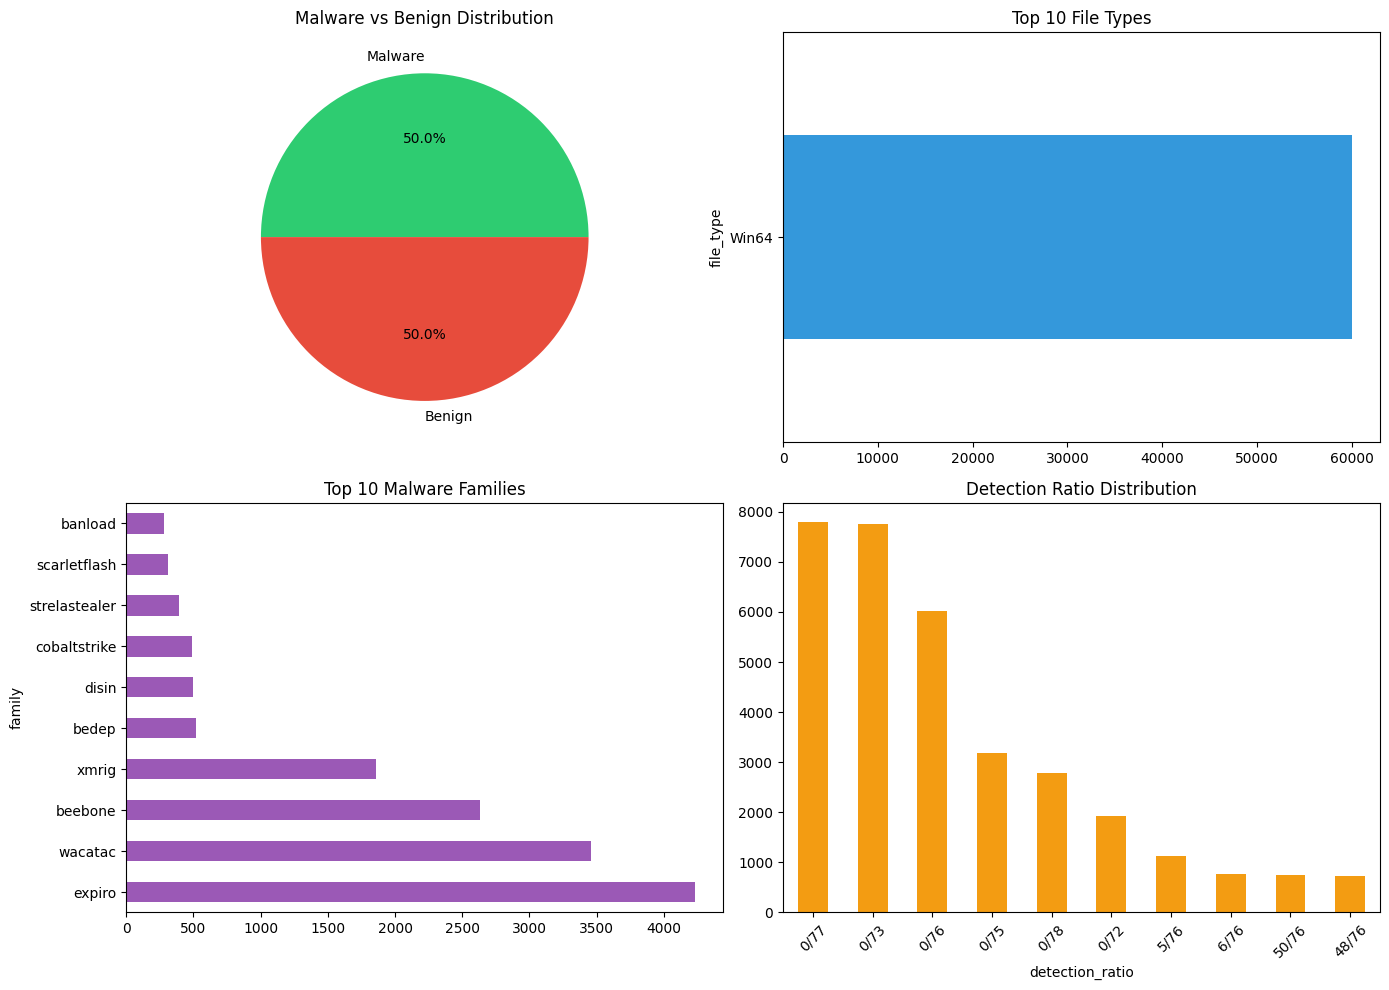

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Label distribution
label_counts = df['label'].value_counts()
axes[0,0].pie(label_counts.values, labels=['Benign' if x==0 else 'Malware' for x in label_counts.index], 
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Malware vs Benign Distribution')

# File type distribution (top 10)
df['file_type'].value_counts().head(10).plot(kind='barh', ax=axes[0,1], color='#3498db')
axes[0,1].set_title('Top 10 File Types')

# Family distribution (top 10, excluding NaN)
df['family'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Top 10 Malware Families')

# Detection ratio distribution
df['detection_ratio'].value_counts().head(10).plot(kind='bar', ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('Detection Ratio Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('malware_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import thrember
import os

# Path where thrember saved the vectorized files
VECTORIZED_PATH = r'C:\Users\user\Desktop\Marcelino\Dataset\Win64_test'

# Check what files were created
print("Files in directory:")
for f in os.listdir(VECTORIZED_PATH):
    print(f"  {f}")

# Load the vectorized features
x_train, y_train = thrember.read_vectorized_features(VECTORIZED_PATH, subset="train")
x_test, y_test = thrember.read_vectorized_features(VECTORIZED_PATH, subset="test")

print(f"\nLoaded - Train: {x_train.shape}, Test: {x_test.shape}")

/home/linux/Documents/GitHub/DAML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-04 17:31:24.394408: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-04 17:31:27.768082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 17:31:36.505091: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Filter unlabeled samples (-1)
train_mask = y_train != -1
test_mask = y_test != -1
x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test = x_test[test_mask], y_test[test_mask]

# Scale ONLY Features (X) - NEVER scale binary labels (y)
scaler_x = MinMaxScaler(feature_range=(0, 1))
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

# Create sequences by grouping features
def create_sequences(X, timesteps=10):
    n_samples, n_features = X.shape
    features_per_step = n_features // timesteps
    target_size = timesteps * features_per_step
    X = X[:, :target_size]
    return X.reshape(n_samples, timesteps, features_per_step)

timesteps = 10
X_train_final = create_sequences(x_train_scaled, timesteps)
X_test_final = create_sequences(x_test_scaled, timesteps)

# Labels stay as 0/1 - NO SCALING
y_train_final = y_train.astype(np.float32)
y_test_final = y_test.astype(np.float32)

print(f"Final shapes - X: {X_train_final.shape}, y: {y_train_final.shape}")

2026-03-04 17:53:03.430321: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-04 17:53:07.833420: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 17:53:17.292738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/linux/Documents/GitHub/DAML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Build LSTM for BINARY CLASSIFICATION
model = Sequential([
    Input(shape=(timesteps, X_train_final.shape[2])),
    LSTM(units=64, return_sequences=True, dropout=0.2),
    BatchNormalization(),
    LSTM(units=32, dropout=0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_final), y=y_train_final)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Train
early_stop = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)

model.fit(
    X_train_final, 
    y_train_final, 
    epochs=20, 
    batch_size=256, 
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

2026-03-04 17:54:06.758338: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-03-04 17:54:08.852353: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1249691520 exceeds 10% of free system memory.


Epoch 1/5
1519/1521 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2597

2026-03-04 17:55:22.783263: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2012901120 exceeds 10% of free system memory.


1521/1521 ━━━━━━━━━━━━━━━━━━━━ 338s 220ms/step - loss: 0.2532 - val_loss: 0.2517
Epoch 2/5
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 87s 26ms/step - loss: 0.2496 - val_loss: 0.2515
Epoch 3/5
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - loss: 0.2486 - val_loss: 0.2537
Epoch 4/5
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - loss: 0.2483 - val_loss: 0.2516
Epoch 5/5
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 0.2470 - val_loss: 0.2530
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step

Forecasted value (original scale): 0.4393332600593567


2026-03-04 18:14:15.759568: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2012901120 exceeds 10% of free system memory.


613/613 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
Precision: 0.5342
Accuracy:  0.5092
F1 Score:  0.0821


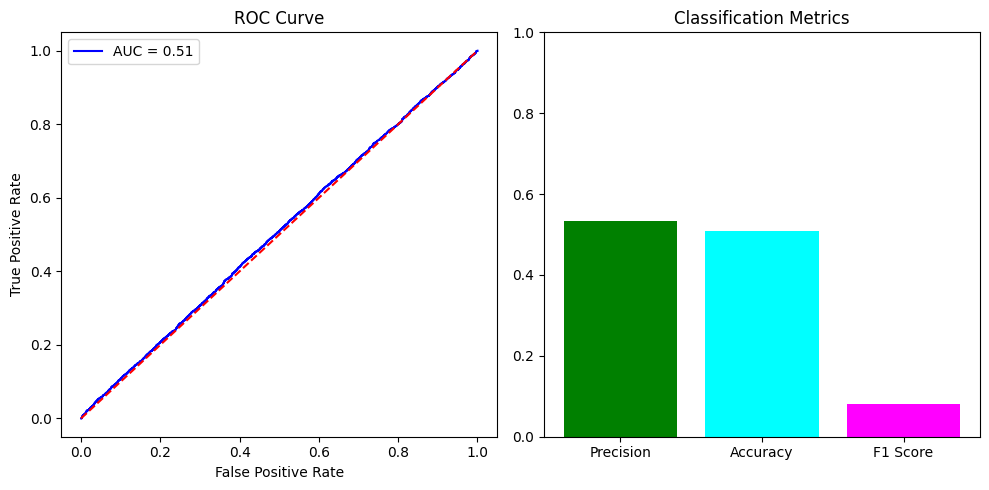

In [ ]:
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Get predictions
y_pred_probs = model.predict(X_test_final)
y_pred_bin = (y_pred_probs > 0.5).astype(int)

# Calculate Metrics
precision = precision_score(y_test_final, y_pred_bin)
accuracy = accuracy_score(y_test_final, y_pred_bin)
f1 = f1_score(y_test_final, y_pred_bin)
recall = recall_score(y_test_final, y_pred_bin)
roc_auc = auc(*roc_curve(y_test_final, y_pred_probs)[:2])

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Plot
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_test_final, y_pred_probs)
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# Metrics Bar Chart
plt.subplot(1, 2, 2)
metrics = ['Precision', 'Recall', 'Accuracy', 'F1']
values = [precision, recall, accuracy, f1]
plt.bar(metrics, values, color=['green', 'orange', 'cyan', 'magenta'])
plt.ylim(0, 1)
plt.title('Classification Metrics')

plt.tight_layout()
plt.show()

In [ ]:
# Save the entire model
model.save('my_lstm_model.keras')
print("Model saved to: my_lstm_model.keras")

# To load later:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('my_lstm_model.keras')